# Set up workspace

In [1]:
import duckdb
import geopandas as gpd
import matplotlib.pyplot as plt

In [2]:
from saidownscale import run_bcsd

# Run through clunky BCSD workflow

In [3]:
RUN_PARAMETERS = {
    "gcm": "CESM2-WACCM",
    "train_period_start": 1978,
    "train_period_end": 2014,
    "predict_period_start": 2015,
    "predict_period_end": 2100,
    "var_name": "tas",
}

In [4]:
# Spatial information if subsetting run to a single country

df = duckdb.sql(
    """install httpfs; load httpfs; install spatial; load spatial; SELECT name, ST_AsText(geom) as geometry FROM ST_Read('https://carbonplan-data.s3.us-west-2.amazonaws.com/countries-50m.json') WHERE NAME = 'South Africa'"""
).df()
df["geometry"] = gpd.GeoSeries.from_wkt(df["geometry"])
south_africa_geom = gpd.GeoDataFrame(df, geometry="geometry")

# Set bounds as a couple of degrees around South Africa
lon_min, lat_min, lon_max, lat_max = south_africa_geom.total_bounds
lon_min = lon_min - 2
lon_max = lon_max + 2
lat_min = lat_min - 2
lat_max = lat_max + 2

subset_bounds = [lat_min, lat_max, lon_min, lon_max]

In [5]:
%%time

# Rechunking in between steps
dict_all = run_bcsd.run_bcsd(
    gcm=RUN_PARAMETERS["gcm"],
    train_period_start=RUN_PARAMETERS["train_period_start"],
    train_period_end=RUN_PARAMETERS["train_period_end"],
    predict_period_start=RUN_PARAMETERS["predict_period_start"],
    predict_period_end=RUN_PARAMETERS["predict_period_end"],
    var_name=RUN_PARAMETERS["var_name"],
    verbose=True,
    rechunk_workflow=True,
    subset_bounds=subset_bounds,
    save_intermediate_output=False,
)

Loaded data: 1.01 seconds
Rechunked obs to full space: 163.79 seconds
Interpolated obs to coarse grid: 68.85 seconds
Rechunked all to full time: 9.43 seconds
Detrended data: 13.81 seconds
Quantile mapped historical: 7.25 seconds
Quantile mapped future: 8.90 seconds
Added back trend: 0.02 seconds
Rechunked to full space for downscaling: 0.38 seconds
Downscaled historical: 8.47 seconds
Downscaled future: 10.04 seconds
Saving to s3://carbonplan-scratch/srm-scratch/v0.3_SouthAfrica/tas_data.zarr


/opt/coiled/env/lib/python3.13/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/opt/coiled/env/lib/python3.13/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


Saved all data: 139.59 seconds
CPU times: user 11min 26s, sys: 2min 44s, total: 14min 11s
Wall time: 7min 11s


# Look at results

In [7]:
from saidownscale.downscaling_utils import get_output_data

In [9]:
# test reading in some saved output data
test = get_output_data(fname_key="model_hist_debiased_downscaled", dtree_key="tas_data.zarr")
test

<xarray.DataTree 'model_hist_debiased_downscaled'>
Group: /model_hist_debiased_downscaled
    Dimensions:    (time: 13505, lat: 115, lon: 102)
    Coordinates:
      * time       (time) datetime64[ns] 108kB 1978-01-01 1978-01-02 ... 2014-12-31
        dayofyear  (time) int64 108kB dask.array<chunksize=(13505,), meta=np.ndarray>
      * lat        (lat) float32 460B -48.75 -48.5 -48.25 ... -20.75 -20.5 -20.25
      * lon        (lon) float32 408B 14.5 14.75 15.0 15.25 ... 39.25 39.5 39.75
    Data variables:
        tas        (time, lat, lon) float32 634MB dask.array<chunksize=(2131, 115, 102), meta=np.ndarray>

In [11]:
dict_all["model_hist_debiased_downscaled"] = (
    dict_all["model_hist_debiased_downscaled"].chunk(time=1000, lat=7, lon=7).compute()
)

In [12]:
dict_all["scenario_debiased_downscaled"] = (
    dict_all["scenario_debiased_downscaled"].chunk(time=1000, lat=7, lon=7).compute()
)

In [13]:
cities = gpd.read_file(
    "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_populated_places_simple.zip",
    columns=["name", "sov0name", "geometry"],
)
sa_cities = cities[cities["sov0name"] == "South Africa"]
cape_town_x, cape_town_y = (
    float(sa_cities[sa_cities["name"] == "Cape Town"].geometry.x.item()),
    float(sa_cities[sa_cities["name"] == "Cape Town"].geometry.y.item()),
)

Text(0.5, 1.0, 'Raw coarse model data')

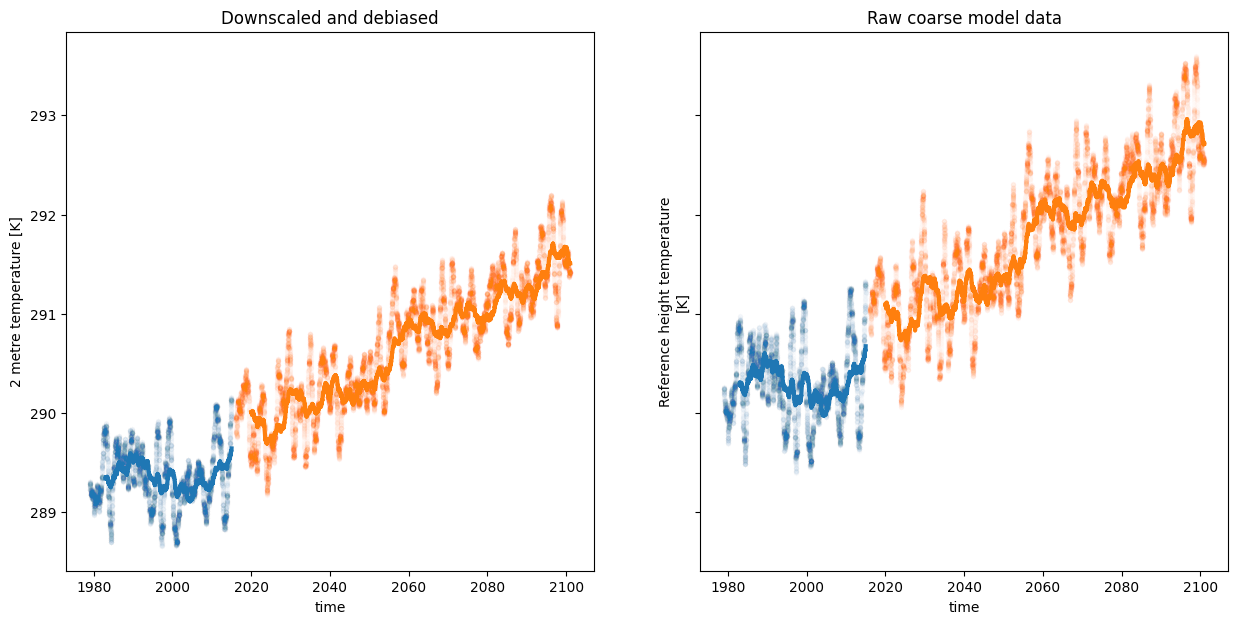

In [14]:
[fig, ax] = plt.subplots(nrows=1, ncols=2, sharey=True, figsize=(15, 7))

plt.subplot(1, 2, 1)
dict_all["model_hist_debiased_downscaled"].sel(
    lat=cape_town_y, lon=cape_town_x, method="nearest"
).rolling(time=365).mean().plot(marker=".", linewidth=0, alpha=0.01, color="C0")
dict_all["model_hist_debiased_downscaled"].sel(
    lat=cape_town_y, lon=cape_town_x, method="nearest"
).rolling(time=365 * 5).mean().plot(color="C0", linewidth=3)

dict_all["scenario_debiased_downscaled"].sel(
    lat=cape_town_y, lon=cape_town_x, method="nearest"
).rolling(time=365).mean().plot(marker=".", linewidth=0, alpha=0.01, color="C1")
dict_all["scenario_debiased_downscaled"].sel(
    lat=cape_town_y, lon=cape_town_x, method="nearest"
).rolling(time=365 * 5).mean().plot(color="C1", linewidth=3)
ax[0].set_title("Downscaled and debiased")

plt.subplot(1, 2, 2)
dict_all["model_hist"].sel(lat=cape_town_y, lon=cape_town_x, method="nearest").rolling(
    time=365
).mean().plot(marker=".", linewidth=0, alpha=0.01, color="C0")
dict_all["model_hist"].sel(lat=cape_town_y, lon=cape_town_x, method="nearest").rolling(
    time=365 * 5
).mean().plot(color="C0", linewidth=3)

dict_all["model_scenario"].sel(lat=cape_town_y, lon=cape_town_x, method="nearest").rolling(
    time=365
).mean().plot(marker=".", linewidth=0, alpha=0.01, color="C1")
dict_all["model_scenario"].sel(lat=cape_town_y, lon=cape_town_x, method="nearest").rolling(
    time=365 * 5
).mean().plot(color="C1", linewidth=3)
ax[1].set_title("Raw coarse model data")